# N-gram TF-IDF EDA of Hearing Utterances

Exploratory analysis of **2-, 3-, and 4-gram TF-IDF** representations of the `text` column in `utterances_sample_labeled.csv`.

**Outline**
1. Load & basic profiling
2. Build TF-IDF matrices (per-n and combined 2–4)
3. Remove n-grams that are contained within longer n-grams (keep only *maximal* n-grams)
4. Top-10 n-grams most correlated with each `speaker.position` and `section` class (one-vs-rest)

In [ ]:
import warnings, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 80)
RANDOM_STATE = 42

DATA_PATH = "utterances_sample_labeled.csv"   # adjust if needed

## 1. Load and profile the data

In [ ]:
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
df = df.dropna(subset=["text"]).copy()
df["text"] = df["text"].astype(str)
df["n_words"] = df["text"].str.split().str.len()
print("After dropping empty text:", df.shape)
df.head(3)

Raw shape: (2619, 8)
After dropping empty text: (2618, 9)


,state,bid,hid,uid,pid,speaker.position,section,text,n_words
0,CA,CA_201520160AB2050,255341,0,55,PRESIDING_CHAIR,INTRO,ORG woman BILL_AUTHOR you have three matters if it's all right with you BILL...,80
1,CA,CA_201520160AB2050,255341,1,101330,BILL_AUTHOR,PRESENTATION,good morning mr chair and members thank you for the opportunity to present B...,369
2,CA,CA_201520160AB2050,255341,2,55,PRESIDING_CHAIR,PRESENTATION,that is correct what they've been doing we've got a variety of bills to try ...,24


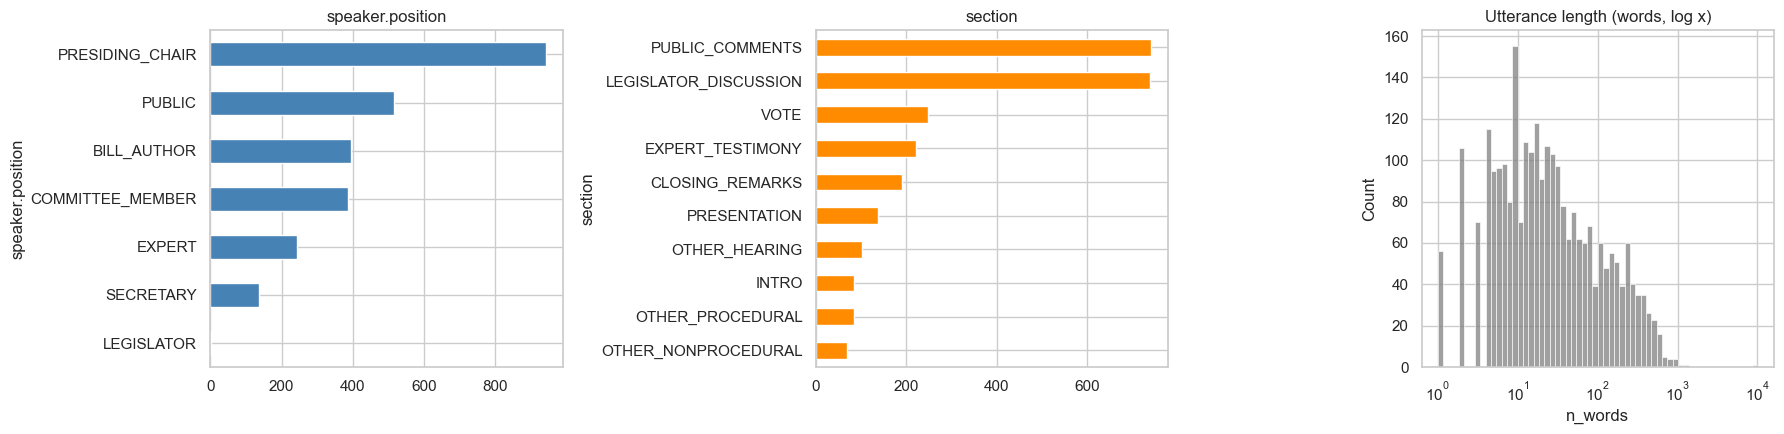

,count,mean,std,min,25%,50%,75%,max
n_words,2618.0,72.124523,231.042878,1.0,8.0,20.0,66.0,10154.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
df["speaker.position"].value_counts().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("speaker.position"); axes[0].invert_yaxis()
df["section"].value_counts().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("section"); axes[1].invert_yaxis()
sns.histplot(df["n_words"], bins=60, log_scale=True, ax=axes[2], color="gray")
axes[2].set_title("Utterance length (words, log x)")
plt.tight_layout(); plt.show()

df["n_words"].describe().to_frame("n_words").T

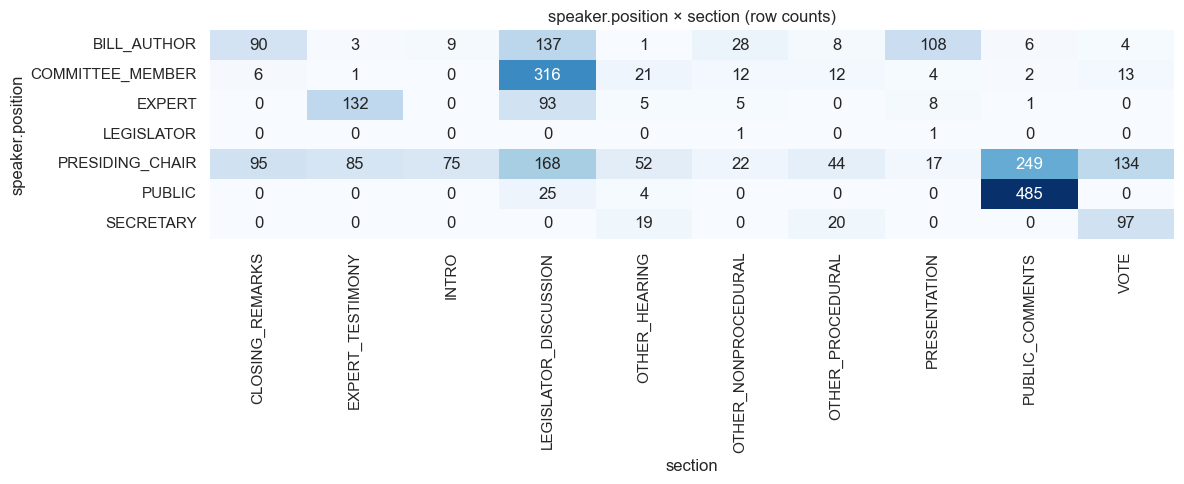

In [ ]:
# Cross-tab of the two label columns — useful context for interpreting clusters later
ct = pd.crosstab(df["speaker.position"], df["section"])
plt.figure(figsize=(12, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("speaker.position × section (row counts)")
plt.tight_layout(); plt.show()

## 2. TF-IDF n-gram features

Notes on preprocessing:
- The text is already lower-cased and has entity placeholders (`ORG`, `BILL`, `BILL_AUTHOR`, `AB2050`, …). We keep these as tokens — they are informative for role/section.
- Token pattern keeps alphanumerics and underscores (so `BILL_AUTHOR` stays one token) and allows 1-char tokens like `i`.
- `min_df=3` drops n-grams that appear in fewer than 3 utterances; `sublinear_tf=True` dampens the very long presentation utterances.
- Utterances are extremely skewed in length (median ≈ 20 words, max > 10k), so L2 row-normalisation (the default) matters.

In [ ]:
TOKEN_PATTERN = r"(?u)\b\w+\b"

def make_vectorizer(ngram_range, min_df=3):
    return TfidfVectorizer(
        ngram_range=ngram_range,
        token_pattern=TOKEN_PATTERN,
        lowercase=False,          # already lower-cased except placeholders; keep case
        min_df=min_df,
        max_df=0.95,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32,
    )

texts = df["text"].tolist()

# Per-n matrices for comparison + combined 2–4 matrix used for clustering & correlations
tfidf = {}
for n in (2, 3, 4):
    vec = make_vectorizer((n, n))
    X = vec.fit_transform(texts)
    tfidf[n] = (vec, X)
    print(f"{n}-grams: {X.shape[1]:>7,} features | nnz/doc = {X.nnz/X.shape[0]:.1f} | "
          f"docs with no feature = {(X.getnnz(axis=1)==0).sum()}")

vec_all = make_vectorizer((2, 4))
X_all = vec_all.fit_transform(texts)
feat_all = np.array(vec_all.get_feature_names_out())
print(f"\ncombined 2–4-grams: {X_all.shape[1]:,} features")

2-grams:   9,890 features | nnz/doc = 36.8 | docs with no feature = 83
3-grams:   5,858 features | nnz/doc = 14.6 | docs with no feature = 323
4-grams:   2,216 features | nnz/doc = 4.9 | docs with no feature = 698

combined 2–4-grams: 17,964 features


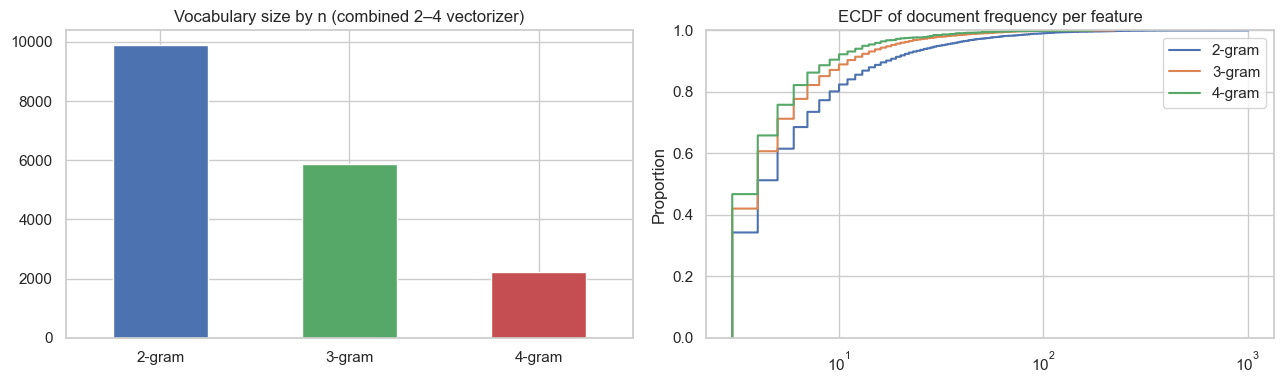

,n_features
2-gram,9890
3-gram,5858
4-gram,2216


In [ ]:
# Vocabulary composition of the combined matrix and sparsity per n
ngram_len = np.array([len(f.split()) for f in feat_all])
comp = pd.Series(ngram_len).value_counts().sort_index().rename("n_features")
comp.index = [f"{i}-gram" for i in comp.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comp.plot.bar(ax=axes[0], color=["#4c72b0", "#55a868", "#c44e52"], rot=0)
axes[0].set_title("Vocabulary size by n (combined 2–4 vectorizer)")

# document frequency distributions
for n, (vec, X) in tfidf.items():
    dfreq = np.asarray((X > 0).sum(axis=0)).ravel()
    sns.ecdfplot(dfreq, ax=axes[1], label=f"{n}-gram", log_scale=True)
axes[1].set_title("ECDF of document frequency per feature"); axes[1].legend()
plt.tight_layout(); plt.show()
comp.to_frame()

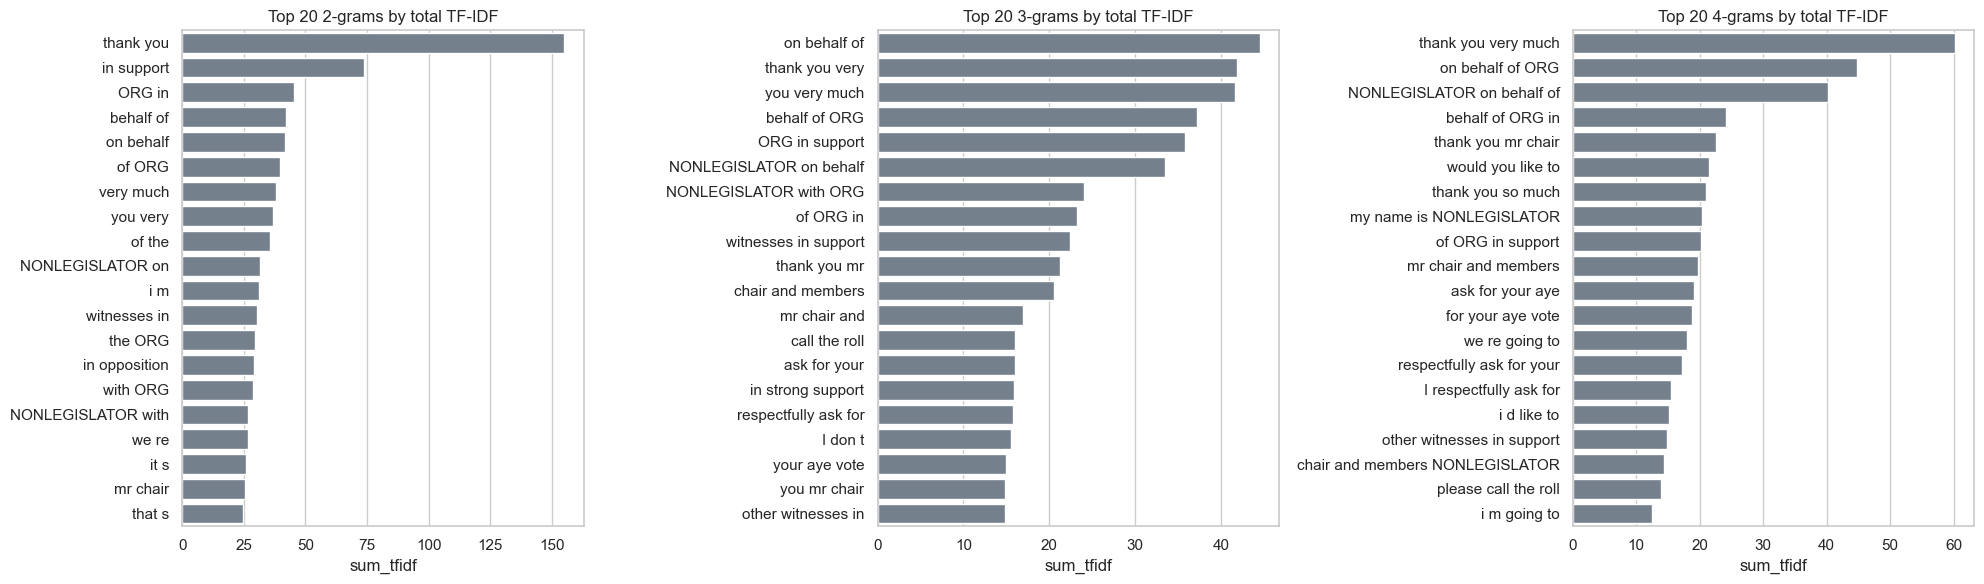

In [ ]:
# Top n-grams by summed TF-IDF weight for each n
def top_features(vec, X, k=20):
    s = np.asarray(X.sum(axis=0)).ravel()
    idx = np.argsort(-s)[:k]
    return pd.DataFrame({"ngram": vec.get_feature_names_out()[idx], "sum_tfidf": s[idx]})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, n in zip(axes, (2, 3, 4)):
    t = top_features(*tfidf[n], k=20)
    sns.barplot(data=t, y="ngram", x="sum_tfidf", ax=ax, color="slategray")
    ax.set_title(f"Top 20 {n}-grams by total TF-IDF"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 3. Keep only maximal n-grams

An n-gram that is contained within a longer n-gram in the vocabulary (`call the` ⊂ `call the roll`, `ask for` ⊂ `respectfully ask for`) carries no information the longer phrase doesn't already carry, and keeping both double-counts the same signal in the embedding and floods the correlation tables with nested variants of one phrase.

So we drop every n-gram that appears as a contiguous sub-sequence of **any** longer n-gram in the TF-IDF vocabulary (i.e. a longer phrase that itself passed `min_df`). Bigrams are tested against trigrams and 4-grams; trigrams against 4-grams; 4-grams are always kept. What survives is the set of *maximal* n-grams.

`CONTAIN_MODE` switches between this strict rule and the earlier frequency-ratio rule (drop when a single longer phrase accounts for ≥ `CONTAIN_THRESHOLD` of the n-gram's occurrences).

In [ ]:
CONTAIN_MODE = "strict"      # "strict": drop if contained in ANY longer vocab n-gram; "ratio": use CONTAIN_THRESHOLD
CONTAIN_THRESHOLD = 0.8      # only used when CONTAIN_MODE == "ratio"

def sub_ngrams(g):
    """All contiguous sub-n-grams (length >= 2) of an n-gram string."""
    t = g.split()
    return [" ".join(t[i:i + k]) for k in range(2, len(t)) for i in range(len(t) - k + 1)]

feat_index = pd.Index(feat_all)

if CONTAIN_MODE == "strict":
    contained_in = {}                                   # sub-ngram -> one longer vocab n-gram that contains it
    for g in feat_all[ngram_len >= 3]:
        for s in sub_ngrams(g):
            contained_in.setdefault(s, g)
    keep_mask = ~feat_index.isin(contained_in.keys())
    absorbed_by = pd.Series(contained_in).reindex(feat_all[~keep_mask])
else:
    from sklearn.feature_extraction.text import CountVectorizer
    cv = CountVectorizer(ngram_range=(2, 4), token_pattern=TOKEN_PATTERN, lowercase=False, dtype=np.int32)
    cnt = pd.Series(np.asarray(cv.fit_transform(texts).sum(axis=0)).ravel(), index=cv.get_feature_names_out())
    cnt_len = cnt.index.str.count(" ") + 1
    best = pd.Series(0.0, index=cnt.index); parent = pd.Series("", index=cnt.index)
    for n in (2, 3):
        sup = cnt[cnt_len == n + 1]
        toks = sup.index.str.split(" ")
        for side in (toks.str[:-1].str.join(" "), toks.str[1:].str.join(" ")):
            m = pd.DataFrame({"p": side, "c": sup.values, "g": sup.index}).sort_values("c").drop_duplicates("p", keep="last").set_index("p")
            better = m["c"].reindex(best.index).fillna(0) > best
            best[better] = m["c"].reindex(best.index)[better]; parent[better] = m["g"].reindex(best.index)[better]
    ratio = (best / cnt).reindex(feat_all).fillna(0.0)
    keep_mask = (ratio < CONTAIN_THRESHOLD).values
    absorbed_by = parent.reindex(feat_all[~keep_mask])

summary = (pd.DataFrame({"order": [f"{n}-gram" for n in ngram_len], "kept": keep_mask})
             .groupby("order")["kept"].agg(total="size", kept="sum"))
summary["dropped"] = summary["total"] - summary["kept"]
summary["dropped_pct"] = (100 * summary["dropped"] / summary["total"]).round(1)
print(f"mode={CONTAIN_MODE}: keeping {keep_mask.sum():,} of {len(feat_all):,} features")
summary

mode=strict: keeping 11,057 of 17,964 features


,total,kept,dropped,dropped_pct
order,,,,
2-gram,9890,5512,4378,44.3
3-gram,5858,3329,2529,43.2
4-gram,2216,2216,0,0.0


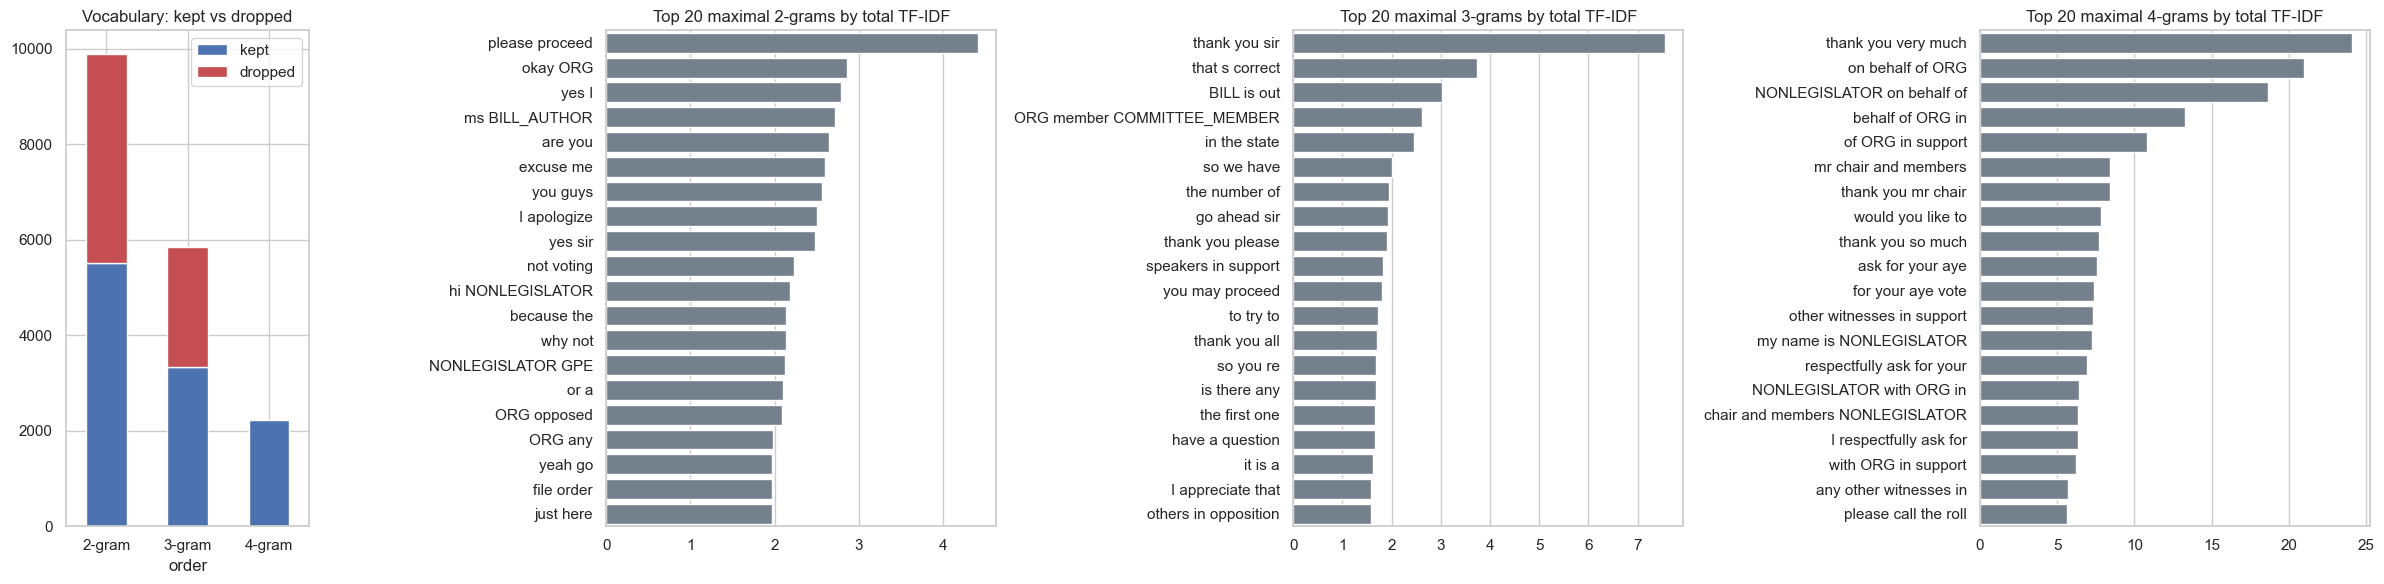

In [ ]:
# Surviving vocabulary by order, and the top surviving n-grams per order
fig, axes = plt.subplots(1, 4, figsize=(24, 6), gridspec_kw={"width_ratios": [1, 1.6, 1.6, 1.6]})
summary[["kept", "dropped"]].plot.bar(stacked=True, ax=axes[0], rot=0, color=["#4c72b0", "#c44e52"])
axes[0].set_title("Vocabulary: kept vs dropped")
s_all = np.asarray(X_all.sum(axis=0)).ravel()
for ax, n in zip(axes[1:], (2, 3, 4)):
    idx = np.where((ngram_len == n) & keep_mask)[0]
    top = idx[np.argsort(-s_all[idx])[:20]]
    sns.barplot(x=s_all[top], y=feat_all[top], ax=ax, color="slategray")
    ax.set_title(f"Top 20 maximal {n}-grams by total TF-IDF"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

In [ ]:
# Apply the filter to the embedding. Unfiltered copies are kept for comparison.
X_all_raw, feat_all_raw, ngram_len_raw = X_all, feat_all, ngram_len

X_all = normalize(X_all_raw[:, keep_mask])     # re-normalise rows after dropping columns
feat_all = feat_all_raw[keep_mask]
ngram_len = ngram_len_raw[keep_mask]
print("Filtered TF-IDF matrix:", X_all.shape,
      "| docs with no remaining feature:", int((X_all.getnnz(axis=1) == 0).sum()))

Filtered TF-IDF matrix: (2618, 11057) | docs with no remaining feature: 266


## 4. N-grams most correlated with each class (one-vs-rest)

For every n-gram feature *x* and every class *c*, we compute the **Pearson correlation** between the TF-IDF column *x* and the binary indicator `1[label == c]` (a point-biserial correlation). A high positive value means the n-gram is heavily weighted in class *c* relative to all other classes. This is computed fully sparse so it scales to the whole vocabulary.

Classes with fewer than `MIN_CLASS_SIZE` utterances are skipped (correlations there are pure noise).

In [ ]:
MIN_CLASS_SIZE = 10

def ngram_class_correlations(X, labels, feats):
    """Return DataFrame [features × classes] of Pearson r between each TF-IDF column and each one-vs-rest indicator."""
    X = sparse.csc_matrix(X, dtype=np.float64)
    n = X.shape[0]
    classes = [c for c, cnt in pd.Series(labels).value_counts().items() if cnt >= MIN_CLASS_SIZE]
    Y = np.column_stack([(labels == c).astype(np.float64) for c in classes])   # n × C

    mean_x = np.asarray(X.mean(axis=0)).ravel()
    mean_x2 = np.asarray(X.multiply(X).mean(axis=0)).ravel()
    sd_x = np.sqrt(np.maximum(mean_x2 - mean_x**2, 0))
    mean_y = Y.mean(axis=0)
    sd_y = np.sqrt(mean_y * (1 - mean_y))

    cov = (X.T @ Y) / n - np.outer(mean_x, mean_y)                            # V × C
    with np.errstate(divide="ignore", invalid="ignore"):
        r = cov / np.outer(sd_x, sd_y)
    r[~np.isfinite(r)] = 0.0
    return pd.DataFrame(r, index=feats, columns=classes)

def top_k_per_class(corr, k=10):
    frames = []
    for c in corr.columns:
        s = corr[c].nlargest(k)
        frames.append(pd.DataFrame({"class": c, "rank": range(1, k + 1), "ngram": s.index, "r": s.values}))
    return pd.concat(frames, ignore_index=True)

def plot_top_ngrams(top, title, ncols=3):
    classes = top["class"].unique()
    nrows = int(np.ceil(len(classes) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 3.6 * nrows), squeeze=False)
    for ax, c in zip(axes.ravel(), classes):
        sub = top[top["class"] == c]
        sns.barplot(data=sub, y="ngram", x="r", ax=ax, color="steelblue")
        ax.set_title(f"{c} (n={int((df[title]==c).sum())})", fontsize=11); ax.set_ylabel(""); ax.set_xlabel("Pearson r (one-vs-rest)")
        ax.tick_params(axis="y", labelsize=8.5)
    for ax in axes.ravel()[len(classes):]:
        ax.axis("off")
    fig.suptitle(f"Top-10 n-grams by correlation with {title}", fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

### 4a. `speaker.position`

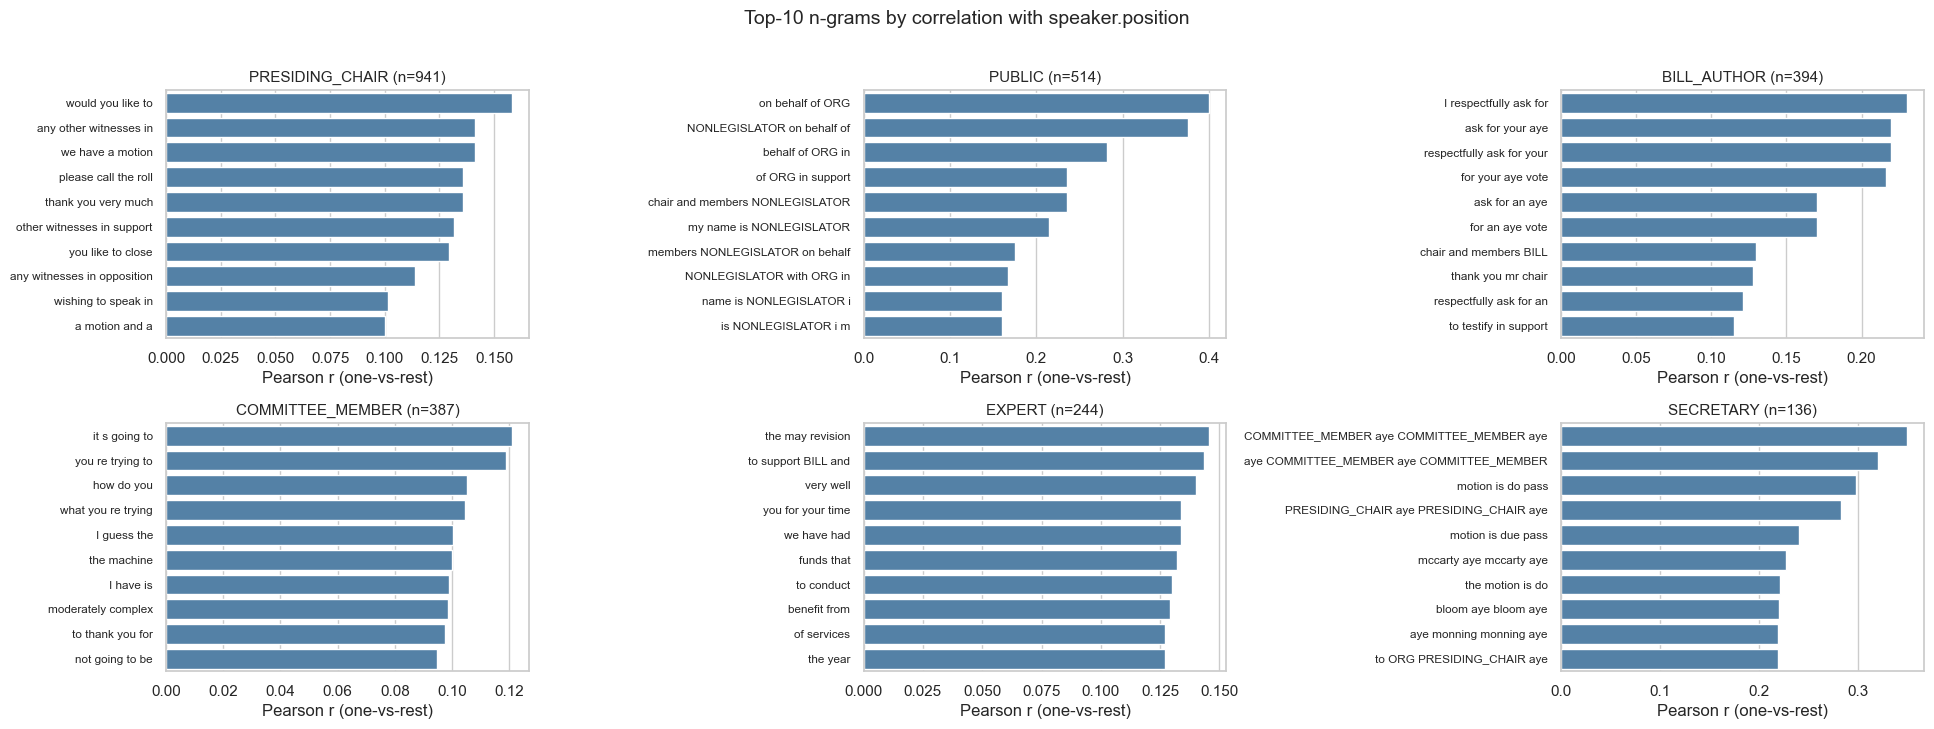

class,BILL_AUTHOR,COMMITTEE_MEMBER,EXPERT,PRESIDING_CHAIR,PUBLIC,SECRETARY
rank,,,,,,
1,I respectfully ask for,it s going to,the may revision,would you like to,on behalf of ORG,COMMITTEE_MEMBER aye COMMITTEE_MEMBER aye
2,ask for your aye,you re trying to,to support BILL and,any other witnesses in,NONLEGISLATOR on behalf of,aye COMMITTEE_MEMBER aye COMMITTEE_MEMBER
3,respectfully ask for your,how do you,very well,we have a motion,behalf of ORG in,motion is do pass
4,for your aye vote,what you re trying,you for your time,please call the roll,of ORG in support,PRESIDING_CHAIR aye PRESIDING_CHAIR aye
5,ask for an aye,I guess the,we have had,thank you very much,chair and members NONLEGISLATOR,motion is due pass
6,for an aye vote,the machine,funds that,other witnesses in support,my name is NONLEGISLATOR,mccarty aye mccarty aye
7,chair and members BILL,I have is,to conduct,you like to close,members NONLEGISLATOR on behalf,the motion is do
8,thank you mr chair,moderately complex,benefit from,any witnesses in opposition,NONLEGISLATOR with ORG in,bloom aye bloom aye
9,respectfully ask for an,to thank you for,of services,wishing to speak in,name is NONLEGISLATOR i,aye monning monning aye


In [ ]:
corr_speaker = ngram_class_correlations(X_all, df["speaker.position"].values, feat_all)
top_speaker = top_k_per_class(corr_speaker, k=10)
plot_top_ngrams(top_speaker, "speaker.position")
top_speaker.pivot(index="rank", columns="class", values="ngram")

### 4b. `section`

In [ ]:
# corr_section = ngram_class_correlations(X_all, df["section"].values, feat_all)
# top_section = top_k_per_class(corr_section, k=10)
# plot_top_ngrams(top_section, "section", ncols=3)
# top_section.pivot(index="rank", columns="class", values="ngram")

### 4c. Breakdown by n-gram order

Are the most discriminative features mostly bigrams, or do longer phrases carry signal too? Below: for each class, the top-10 correlated features restricted to each order separately.

In [ ]:
# Strength of the single best feature per class — how separable is each class in n-gram space?
best = pd.concat({
    "speaker.position": corr_speaker.max(axis=0),
    "section": corr_section.max(axis=0),
}, names=["label", "class"]).reset_index(name="max_r")
plt.figure(figsize=(10, 4.5))
sns.barplot(data=best.sort_values("max_r", ascending=False), x="class", y="max_r", hue="label", dodge=False)
plt.xticks(rotation=45, ha="right"); plt.ylabel("max Pearson r over all n-grams"); plt.xlabel("")
plt.title("Best single n-gram correlation per class"); plt.tight_layout(); plt.show()

NameError: name 'corr_section' is not defined